
# Portfolio Risk Reporting

## Credit Risk Intelligence Lab

This notebook consolidates the analytical layers built in the previous notebooks into a portfolio-level credit risk report.

The project has already produced several borrower-level views:

1. **Probability of Default (PD)** from the supervised model.
2. **Risk clusters** from unsupervised segmentation.
3. **Anomaly scores** from anomaly detection.
4. **Model explanations** from the interpretability layer.

This notebook moves from borrower-level analytics to portfolio-level risk intelligence. The objective is to answer questions such as:

- How much exposure is concentrated in high-risk borrowers?
- Which clusters contribute the most to expected loss?
- Are anomalous borrowers also riskier or simply unusual?
- Which segments deserve portfolio monitoring?
- What are the key risk indicators that should appear in a credit risk dashboard?

The notebook does not replace a production risk report. It creates a first structured reporting layer for the Credit Risk Intelligence Lab.



## Notebook objectives

This notebook focuses on eight tasks:

1. Load the outputs generated by the supervised, unsupervised, anomaly, and interpretability notebooks.
2. Build a consolidated portfolio risk table.
3. Create portfolio-level key risk indicators.
4. Summarize exposure, PD, observed default, and expected loss by risk band.
5. Summarize credit risk by unsupervised segment.
6. Analyze anomaly exposure and anomaly contribution to expected loss.
7. Build concentration and ranking views.
8. Save portfolio reporting tables, figures, and a markdown executive report.

The next notebook should focus specifically on stress testing and scenario analysis.


In [1]:

from pathlib import Path
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")



## Project paths

The notebook is designed to run either from the project root or from the `notebooks/` directory.


In [2]:

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_FIGURES = REPORTS_DIR / "figures"
REPORTS_TABLES = REPORTS_DIR / "tables"
MODELS_DIR = PROJECT_ROOT / "models"

for path in [DATA_PROCESSED, REPORTS_DIR, REPORTS_FIGURES, REPORTS_TABLES, MODELS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data path: {DATA_PROCESSED}")
print(f"Reports path: {REPORTS_DIR}")
print(f"Figures path: {REPORTS_FIGURES}")
print(f"Tables path: {REPORTS_TABLES}")


Project root: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab
Processed data path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/data/processed
Reports path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/reports
Figures path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/reports/figures
Tables path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/reports/tables



## Load previous analytical outputs

This notebook is meant to run after notebooks 03, 04, 05, and 06.

The most important input is:

```text
data/processed/credit_risk_segments.csv
```

That file contains the full portfolio with predicted PD, risk cluster, exposure proxy, and expected loss proxy. Anomaly and interpretability outputs are attached when available.


In [3]:

required_files = {
    "segments": DATA_PROCESSED / "credit_risk_segments.csv",
}

optional_files = {
    "anomalies": DATA_PROCESSED / "credit_risk_anomaly_scores.csv",
    "interpretability": DATA_PROCESSED / "credit_risk_interpretability_output.csv",
    "cluster_summary": REPORTS_TABLES / "04_cluster_risk_summary.csv",
    "model_metrics": REPORTS_TABLES / "03_model_metrics.csv",
}

missing_files = [name for name, path in required_files.items() if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Missing required files: "
        + ", ".join(missing_files)
        + ". Run notebooks 03, 04, 05, and 06 before this notebook."
    )

portfolio = pd.read_csv(required_files["segments"], index_col=0)
portfolio.index = portfolio.index.astype(str)

loaded_optional = {}

for name, path in optional_files.items():
    if path.exists():
        loaded_optional[name] = pd.read_csv(path, index_col=0)
        loaded_optional[name].index = loaded_optional[name].index.astype(str)
        print(f"Loaded optional file: {name} -> {loaded_optional[name].shape}")
    else:
        print(f"Optional file not found: {name}")

print(f"Portfolio base table: {portfolio.shape}")
portfolio.head()


Loaded optional file: anomalies -> (1000, 14)
Loaded optional file: interpretability -> (200, 42)
Loaded optional file: cluster_summary -> (2, 13)
Loaded optional file: model_metrics -> (2, 8)
Portfolio base table: (1000, 35)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct_income,personal_status_sex,other_debtors_guarantors,present_residence_since,property,age_years,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_amount_per_month,credit_amount_log,duration_years,long_duration_flag,high_credit_amount_flag,installment_burden_proxy,age_bucket,duration_bucket,credit_amount_bucket,actual_default,predicted_pd,risk_cluster,ead_proxy,expected_loss_proxy,agg_cluster
828,A11,36,A32,A41,8335,A65,A75,3,A93,A101,4,A124,47,A143,A153,1,A173,1,A191,A201,231.5278,9.0283,3.0000,1,1,25005,mid_career,long_term,high_amount,1,0.5487,1,8335,"2,058.0017",0
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,4,A123,38,A143,A152,1,A173,1,A191,A201,67.0000,6.6908,1.0000,0,0,3216,mid_career,short_term,low_amount,0,0.1170,0,804,42.3423,1
148,A11,36,A34,A42,5371,A61,A73,3,A93,A103,2,A122,28,A143,A152,2,A173,1,A191,A201,149.1944,8.5890,3.0000,1,1,16113,early_career,long_term,high_amount,0,0.6783,1,5371,"1,639.4020",0
735,A12,36,A31,A44,3990,A65,A72,3,A92,A101,2,A124,29,A141,A152,1,A171,1,A191,A201,110.8333,8.2918,3.0000,1,1,11970,early_career,long_term,high_amount,0,0.9167,1,3990,"1,645.9621",0
130,A12,48,A32,A40,8487,A65,A74,1,A92,A101,2,A123,24,A143,A152,1,A173,1,A191,A201,176.8125,9.0464,4.0000,1,1,8487,young,very_long_term,high_amount,0,0.5706,1,8487,"2,179.1908",0



## Build consolidated portfolio table

This section creates a single master table with the most relevant portfolio risk fields.

The portfolio table should include:

- Actual default label.
- Predicted probability of default.
- Risk cluster.
- Exposure proxy.
- Expected loss proxy.
- Anomaly score and anomaly flag when available.
- Risk band and exposure group.


In [4]:

portfolio_report = portfolio.copy()

# Attach anomaly outputs when available.
if "anomalies" in loaded_optional:
    anomalies = loaded_optional["anomalies"]
    anomaly_cols = [
        col for col in [
            "ensemble_anomaly_score",
            "ensemble_anomaly_flag",
            "if_score_scaled",
            "lof_score_scaled",
        ]
        if col in anomalies.columns
    ]
    if anomaly_cols:
        portfolio_report = portfolio_report.join(
            anomalies[anomaly_cols],
            how="left",
            rsuffix="_anomaly",
        )

# Attach interpretability outputs when available.
if "interpretability" in loaded_optional:
    interpretability = loaded_optional["interpretability"]
    interpretation_cols = [
        col for col in [
            "top_positive_contributors",
            "top_negative_contributors",
            "risk_narrative",
        ]
        if col in interpretability.columns
    ]
    if interpretation_cols:
        portfolio_report = portfolio_report.join(
            interpretability[interpretation_cols],
            how="left",
            rsuffix="_interpretability",
        )

# Ensure core portfolio fields exist.
LGD_ASSUMPTION = 0.45

if "ead_proxy" not in portfolio_report.columns:
    portfolio_report["ead_proxy"] = portfolio_report["credit_amount"]

if "expected_loss_proxy" not in portfolio_report.columns:
    portfolio_report["expected_loss_proxy"] = (
        portfolio_report["predicted_pd"] * LGD_ASSUMPTION * portfolio_report["ead_proxy"]
    )

def assign_pd_band(pd_value: float) -> str:
    if pd.isna(pd_value):
        return "missing_pd"
    if pd_value < 0.20:
        return "low_risk"
    elif pd_value < 0.40:
        return "moderate_risk"
    elif pd_value < 0.60:
        return "elevated_risk"
    else:
        return "high_risk"

portfolio_report["risk_band"] = portfolio_report["predicted_pd"].apply(assign_pd_band)

portfolio_report["exposure_bucket"] = pd.qcut(
    portfolio_report["ead_proxy"],
    q=4,
    labels=["low_exposure", "medium_low_exposure", "medium_high_exposure", "high_exposure"],
    duplicates="drop",
)

if "ensemble_anomaly_flag" not in portfolio_report.columns:
    portfolio_report["ensemble_anomaly_flag"] = 0

if "ensemble_anomaly_score" not in portfolio_report.columns:
    portfolio_report["ensemble_anomaly_score"] = np.nan

portfolio_report.head()


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct_income,personal_status_sex,other_debtors_guarantors,present_residence_since,property,age_years,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_amount_per_month,credit_amount_log,duration_years,long_duration_flag,high_credit_amount_flag,installment_burden_proxy,age_bucket,duration_bucket,credit_amount_bucket,actual_default,predicted_pd,risk_cluster,ead_proxy,expected_loss_proxy,agg_cluster,ensemble_anomaly_score,ensemble_anomaly_flag,if_score_scaled,lof_score_scaled,top_positive_contributors,top_negative_contributors,risk_narrative,risk_band,exposure_bucket
828,A11,36,A32,A41,8335,A65,A75,3,A93,A101,4,A124,47,A143,A153,1,A173,1,A191,A201,231.5278,9.0283,3.0000,1,1,25005,mid_career,long_term,high_amount,1,0.5487,1,8335,"2,058.0017",0,0.2145,0,0.4163,0.0128,NaN,NaN,NaN,elevated_risk,high_exposure
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,4,A123,38,A143,A152,1,A173,1,A191,A201,67.0000,6.6908,1.0000,0,0,3216,mid_career,short_term,low_amount,0,0.1170,0,804,42.3423,1,0.0010,0,0.0002,0.0017,NaN,NaN,NaN,low_risk,low_exposure
148,A11,36,A34,A42,5371,A61,A73,3,A93,A103,2,A122,28,A143,A152,2,A173,1,A191,A201,149.1944,8.5890,3.0000,1,1,16113,early_career,long_term,high_amount,0,0.6783,1,5371,"1,639.4020",0,0.1913,0,0.3777,0.0048,NaN,NaN,NaN,high_risk,high_exposure
735,A12,36,A31,A44,3990,A65,A72,3,A92,A101,2,A124,29,A141,A152,1,A171,1,A191,A201,110.8333,8.2918,3.0000,1,1,11970,early_career,long_term,high_amount,0,0.9167,1,3990,"1,645.9621",0,0.3607,1,0.7040,0.0174,NaN,NaN,NaN,high_risk,high_exposure
130,A12,48,A32,A40,8487,A65,A74,1,A92,A101,2,A123,24,A143,A152,1,A173,1,A191,A201,176.8125,9.0464,4.0000,1,1,8487,young,very_long_term,high_amount,0,0.5706,1,8487,"2,179.1908",0,0.2260,0,0.4376,0.0145,NaN,NaN,NaN,elevated_risk,high_exposure



## Portfolio key risk indicators

A portfolio risk report should start with a compact executive view.

The following indicators summarize portfolio size, exposure, average PD, observed default rate, expected loss proxy, anomaly rate, and concentration.


In [5]:

def herfindahl_index(values: pd.Series) -> float:
    total = values.sum()
    if total == 0:
        return np.nan
    shares = values / total
    return float((shares ** 2).sum())

portfolio_kpis = {
    "number_of_borrowers": int(len(portfolio_report)),
    "total_exposure_proxy": float(portfolio_report["ead_proxy"].sum()),
    "average_exposure_proxy": float(portfolio_report["ead_proxy"].mean()),
    "average_predicted_pd": float(portfolio_report["predicted_pd"].mean()),
    "median_predicted_pd": float(portfolio_report["predicted_pd"].median()),
    "observed_default_rate": float(portfolio_report["actual_default"].mean()),
    "total_expected_loss_proxy": float(portfolio_report["expected_loss_proxy"].sum()),
    "expected_loss_rate_proxy": float(
        portfolio_report["expected_loss_proxy"].sum() / portfolio_report["ead_proxy"].sum()
    ),
    "anomaly_rate": float(portfolio_report["ensemble_anomaly_flag"].mean()),
    "exposure_hhi_by_borrower": herfindahl_index(portfolio_report["ead_proxy"]),
}

portfolio_kpis_df = pd.DataFrame(
    list(portfolio_kpis.items()),
    columns=["metric", "value"],
)

portfolio_kpis_df


,metric,value
0,number_of_borrowers,"1,000.0000"
1,total_exposure_proxy,"3,271,258.0000"
2,average_exposure_proxy,"3,271.2580"
3,average_predicted_pd,0.4319
4,median_predicted_pd,0.4000
5,observed_default_rate,0.3000
6,total_expected_loss_proxy,"732,747.3497"
7,expected_loss_rate_proxy,0.2240
8,anomaly_rate,0.0500
9,exposure_hhi_by_borrower,0.0017



## Risk band summary

Risk bands translate raw predicted probabilities into a reporting format that is easier to monitor.

The thresholds are illustrative and should not be interpreted as final underwriting policy.


In [6]:

risk_band_order = ["high_risk", "elevated_risk", "moderate_risk", "low_risk", "missing_pd"]

risk_band_summary = (
    portfolio_report
    .groupby("risk_band")
    .agg(
        borrowers=("actual_default", "size"),
        observed_defaults=("actual_default", "sum"),
        observed_default_rate=("actual_default", "mean"),
        avg_predicted_pd=("predicted_pd", "mean"),
        median_predicted_pd=("predicted_pd", "median"),
        exposure_proxy=("ead_proxy", "sum"),
        avg_exposure_proxy=("ead_proxy", "mean"),
        expected_loss_proxy=("expected_loss_proxy", "sum"),
        anomaly_rate=("ensemble_anomaly_flag", "mean"),
    )
    .assign(
        borrower_share=lambda x: x["borrowers"] / len(portfolio_report),
        exposure_share=lambda x: x["exposure_proxy"] / x["exposure_proxy"].sum(),
        expected_loss_share=lambda x: x["expected_loss_proxy"] / x["expected_loss_proxy"].sum(),
    )
)

risk_band_summary = risk_band_summary.reindex(
    [band for band in risk_band_order if band in risk_band_summary.index]
)

risk_band_summary


,borrowers,observed_defaults,observed_default_rate,avg_predicted_pd,median_predicted_pd,exposure_proxy,avg_exposure_proxy,expected_loss_proxy,anomaly_rate,borrower_share,exposure_share,expected_loss_share
risk_band,,,,,,,,,,,,
high_risk,322,201,0.6242,0.7859,0.7905,1300055,"4,037.4379","473,754.6413",0.0963,0.3220,0.3974,0.6465
elevated_risk,178,58,0.3258,0.5027,0.5033,647615,"3,638.2865","149,564.1918",0.0506,0.1780,0.1980,0.2041
moderate_risk,198,26,0.1313,0.3008,0.3093,546772,"2,761.4747","74,844.3773",0.0303,0.1980,0.1671,0.1021
low_risk,302,15,0.0497,0.0986,0.0963,776816,"2,572.2384","34,584.1392",0.0132,0.3020,0.2375,0.0472


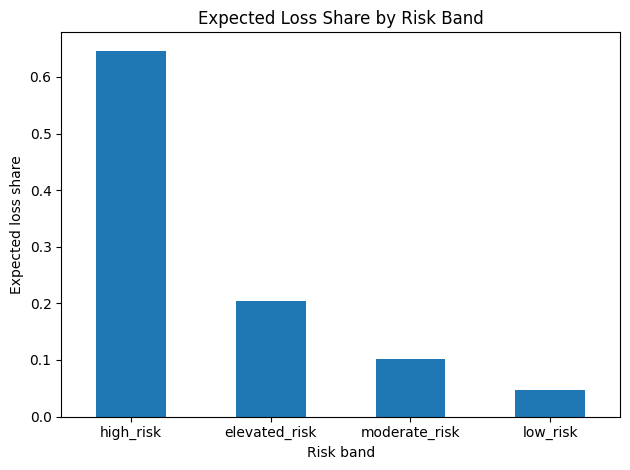

In [7]:

fig, ax = plt.subplots()

risk_band_summary["expected_loss_share"].plot(kind="bar", ax=ax)

ax.set_title("Expected Loss Share by Risk Band")
ax.set_xlabel("Risk band")
ax.set_ylabel("Expected loss share")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "07_expected_loss_share_by_risk_band.png", dpi=150)
plt.show();


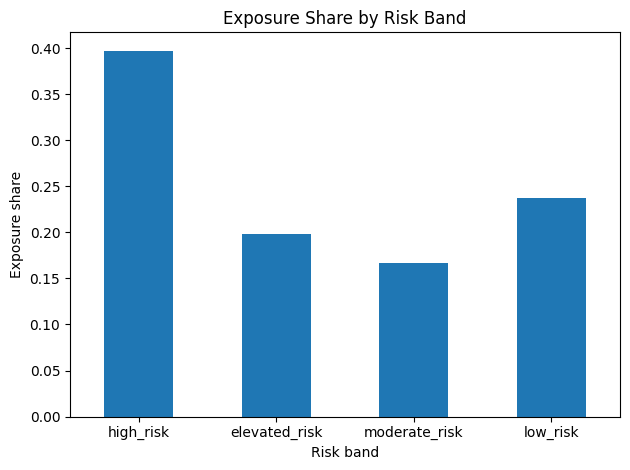

In [8]:

fig, ax = plt.subplots()

risk_band_summary["exposure_share"].plot(kind="bar", ax=ax)

ax.set_title("Exposure Share by Risk Band")
ax.set_xlabel("Risk band")
ax.set_ylabel("Exposure share")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "07_exposure_share_by_risk_band.png", dpi=150)
plt.show();



## Cluster risk summary

The unsupervised risk clusters from notebook 04 allow the portfolio to be monitored by hidden borrower segment.

This is important because expected loss may be concentrated in clusters that are not obvious from individual PD scores alone.


In [9]:

cluster_summary = (
    portfolio_report
    .groupby("risk_cluster")
    .agg(
        borrowers=("actual_default", "size"),
        observed_defaults=("actual_default", "sum"),
        observed_default_rate=("actual_default", "mean"),
        avg_predicted_pd=("predicted_pd", "mean"),
        median_predicted_pd=("predicted_pd", "median"),
        exposure_proxy=("ead_proxy", "sum"),
        avg_exposure_proxy=("ead_proxy", "mean"),
        expected_loss_proxy=("expected_loss_proxy", "sum"),
        anomaly_rate=("ensemble_anomaly_flag", "mean"),
        avg_anomaly_score=("ensemble_anomaly_score", "mean"),
        avg_duration_months=("duration_months", "mean"),
        avg_age=("age_years", "mean"),
    )
    .assign(
        borrower_share=lambda x: x["borrowers"] / len(portfolio_report),
        exposure_share=lambda x: x["exposure_proxy"] / x["exposure_proxy"].sum(),
        expected_loss_share=lambda x: x["expected_loss_proxy"] / x["expected_loss_proxy"].sum(),
    )
    .sort_values("expected_loss_share", ascending=False)
)

cluster_summary


,borrowers,observed_defaults,observed_default_rate,avg_predicted_pd,median_predicted_pd,exposure_proxy,avg_exposure_proxy,expected_loss_proxy,anomaly_rate,avg_anomaly_score,avg_duration_months,avg_age,borrower_share,exposure_share,expected_loss_share
risk_cluster,,,,,,,,,,,,,,,
1,282,120,0.4255,0.5624,0.5901,1913969,"6,787.1241","508,266.5752",0.1348,0.2463,33.5461,36.1418,0.2820,0.5851,0.6936
0,718,180,0.2507,0.3806,0.3341,1357289,"1,890.3747","224,480.7744",0.0167,0.1567,15.9373,35.3120,0.7180,0.4149,0.3064


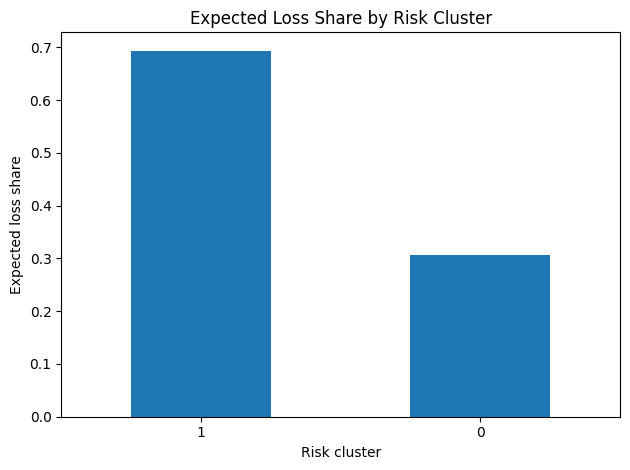

In [10]:

fig, ax = plt.subplots()

cluster_summary["expected_loss_share"].plot(kind="bar", ax=ax)

ax.set_title("Expected Loss Share by Risk Cluster")
ax.set_xlabel("Risk cluster")
ax.set_ylabel("Expected loss share")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "07_expected_loss_share_by_cluster.png", dpi=150)
plt.show();


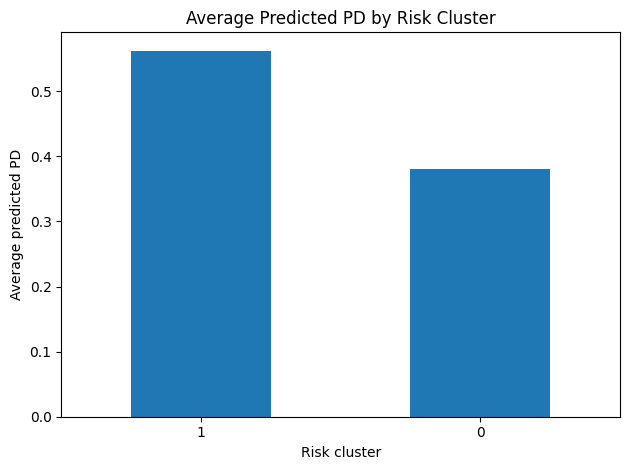

In [11]:

fig, ax = plt.subplots()

cluster_summary["avg_predicted_pd"].plot(kind="bar", ax=ax)

ax.set_title("Average Predicted PD by Risk Cluster")
ax.set_xlabel("Risk cluster")
ax.set_ylabel("Average predicted PD")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "07_average_pd_by_cluster.png", dpi=150)
plt.show();



## Anomaly portfolio view

Anomalous borrowers are not automatically bad borrowers. They are structurally unusual profiles.

This section compares anomalous borrowers and normal borrowers by exposure, PD, observed default rate, and expected loss proxy.


In [12]:

anomaly_summary = (
    portfolio_report
    .groupby("ensemble_anomaly_flag")
    .agg(
        borrowers=("actual_default", "size"),
        observed_default_rate=("actual_default", "mean"),
        avg_predicted_pd=("predicted_pd", "mean"),
        median_predicted_pd=("predicted_pd", "median"),
        exposure_proxy=("ead_proxy", "sum"),
        avg_exposure_proxy=("ead_proxy", "mean"),
        expected_loss_proxy=("expected_loss_proxy", "sum"),
        avg_anomaly_score=("ensemble_anomaly_score", "mean"),
    )
    .assign(
        borrower_share=lambda x: x["borrowers"] / len(portfolio_report),
        exposure_share=lambda x: x["exposure_proxy"] / x["exposure_proxy"].sum(),
        expected_loss_share=lambda x: x["expected_loss_proxy"] / x["expected_loss_proxy"].sum(),
    )
)

anomaly_summary.index = [
    "normal_profile" if idx == 0 else "anomalous_profile"
    for idx in anomaly_summary.index
]

anomaly_summary


,borrowers,observed_default_rate,avg_predicted_pd,median_predicted_pd,exposure_proxy,avg_exposure_proxy,expected_loss_proxy,avg_anomaly_score,borrower_share,exposure_share,expected_loss_share
normal_profile,950,0.2895,0.4194,0.3897,2866952,"3,017.8442","600,467.2153",0.1701,0.9500,0.8764,0.8195
anomalous_profile,50,0.5000,0.6684,0.7249,404306,"8,086.1200","132,280.1344",0.4077,0.0500,0.1236,0.1805


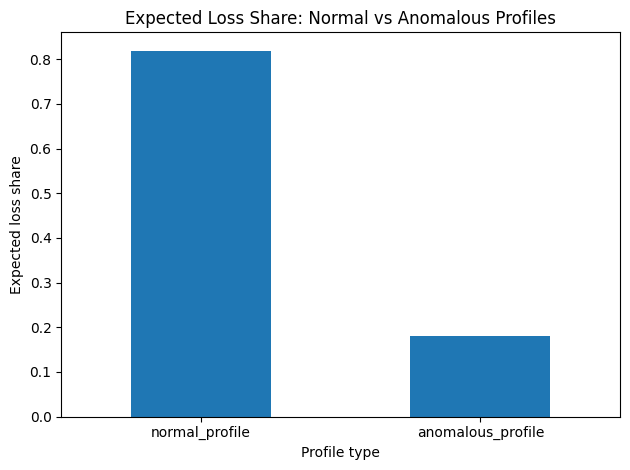

In [13]:

fig, ax = plt.subplots()

anomaly_summary["expected_loss_share"].plot(kind="bar", ax=ax)

ax.set_title("Expected Loss Share: Normal vs Anomalous Profiles")
ax.set_xlabel("Profile type")
ax.set_ylabel("Expected loss share")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "07_expected_loss_share_anomalies.png", dpi=150)
plt.show();



## Cluster and risk band matrix

A risk matrix helps identify where expected loss is concentrated across both supervised and unsupervised views.

Rows represent unsupervised clusters. Columns represent supervised PD risk bands.


In [14]:

cluster_band_matrix = pd.pivot_table(
    portfolio_report,
    values="expected_loss_proxy",
    index="risk_cluster",
    columns="risk_band",
    aggfunc="sum",
    fill_value=0,
)

cluster_band_matrix_share = cluster_band_matrix / cluster_band_matrix.values.sum()

cluster_band_matrix_share


risk_band,elevated_risk,high_risk,low_risk,moderate_risk
risk_cluster,,,,
0,0.0707,0.1528,0.0292,0.0536
1,0.1334,0.4938,0.0179,0.0485


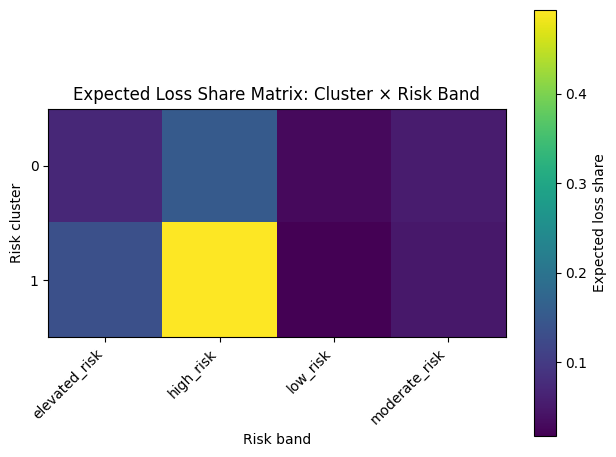

In [15]:

fig, ax = plt.subplots()

im = ax.imshow(cluster_band_matrix_share)

ax.set_title("Expected Loss Share Matrix: Cluster × Risk Band")
ax.set_xlabel("Risk band")
ax.set_ylabel("Risk cluster")

ax.set_xticks(range(len(cluster_band_matrix_share.columns)))
ax.set_xticklabels(cluster_band_matrix_share.columns, rotation=45, ha="right")

ax.set_yticks(range(len(cluster_band_matrix_share.index)))
ax.set_yticklabels(cluster_band_matrix_share.index)

fig.colorbar(im, ax=ax, label="Expected loss share")

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "07_cluster_risk_band_expected_loss_matrix.png", dpi=150)
plt.show();



## Exposure concentration analysis

A portfolio can have acceptable average PD but still be fragile if exposure is concentrated in a few borrowers or risk groups.

This section calculates simple concentration views by borrower, cluster, and risk band.


In [16]:

top_borrowers_by_exposure = (
    portfolio_report
    .sort_values("ead_proxy", ascending=False)
    .head(20)
)

top_borrowers_by_expected_loss = (
    portfolio_report
    .sort_values("expected_loss_proxy", ascending=False)
    .head(20)
)

concentration_summary = pd.DataFrame(
    [
        {
            "concentration_view": "top_10_borrowers_exposure_share",
            "value": top_borrowers_by_exposure.head(10)["ead_proxy"].sum() / portfolio_report["ead_proxy"].sum(),
        },
        {
            "concentration_view": "top_20_borrowers_exposure_share",
            "value": top_borrowers_by_exposure.head(20)["ead_proxy"].sum() / portfolio_report["ead_proxy"].sum(),
        },
        {
            "concentration_view": "top_10_borrowers_expected_loss_share",
            "value": top_borrowers_by_expected_loss.head(10)["expected_loss_proxy"].sum() / portfolio_report["expected_loss_proxy"].sum(),
        },
        {
            "concentration_view": "top_20_borrowers_expected_loss_share",
            "value": top_borrowers_by_expected_loss.head(20)["expected_loss_proxy"].sum() / portfolio_report["expected_loss_proxy"].sum(),
        },
        {
            "concentration_view": "exposure_hhi_by_borrower",
            "value": herfindahl_index(portfolio_report["ead_proxy"]),
        },
        {
            "concentration_view": "exposure_hhi_by_cluster",
            "value": herfindahl_index(cluster_summary["exposure_proxy"]),
        },
        {
            "concentration_view": "expected_loss_hhi_by_cluster",
            "value": herfindahl_index(cluster_summary["expected_loss_proxy"]),
        },
    ]
)

concentration_summary


,concentration_view,value
0,top_10_borrowers_exposure_share,0.0472
1,top_20_borrowers_exposure_share,0.0870
2,top_10_borrowers_expected_loss_share,0.0853
3,top_20_borrowers_expected_loss_share,0.1496
4,exposure_hhi_by_borrower,0.0017
5,exposure_hhi_by_cluster,0.5145
6,expected_loss_hhi_by_cluster,0.5750


In [17]:

review_columns = [
    "predicted_pd",
    "actual_default",
    "risk_band",
    "risk_cluster",
    "ensemble_anomaly_score",
    "ensemble_anomaly_flag",
    "credit_amount",
    "duration_months",
    "age_years",
    "ead_proxy",
    "expected_loss_proxy",
]

available_review_columns = [col for col in review_columns if col in portfolio_report.columns]

top_borrowers_by_expected_loss[available_review_columns].head(20)


,predicted_pd,actual_default,risk_band,risk_cluster,ensemble_anomaly_score,ensemble_anomaly_flag,credit_amount,duration_months,age_years,ead_proxy,expected_loss_proxy
95,0.9893,1,high_risk,1,0.4313,1,15945,54,58,15945,"7,098.1684"
818,0.9567,0,high_risk,1,0.4431,1,15857,36,43,15857,"6,826.7076"
917,0.9985,1,high_risk,1,0.8795,1,14896,6,68,14896,"6,692.8696"
374,0.9752,1,high_risk,1,0.5432,1,14782,60,60,14782,"6,487.1436"
236,0.9573,1,high_risk,1,0.8353,1,14555,6,23,14555,"6,270.3416"
378,0.9704,1,high_risk,1,0.3504,1,14318,36,57,14318,"6,252.4352"
714,0.9711,1,high_risk,1,0.3063,0,14027,60,27,14027,"6,129.5311"
63,0.8836,1,high_risk,1,0.2839,0,14421,48,25,14421,"5,734.1207"
887,0.7976,1,high_risk,1,0.2407,0,15672,48,23,15672,"5,624.8403"
915,0.6485,1,high_risk,1,0.4656,1,18424,48,32,18424,"5,376.9306"



## Calibration-style portfolio view

This section compares average predicted PD against observed default rate by risk band.

This is not a full statistical calibration study. It is a portfolio reporting view that helps identify whether the model's risk bands are directionally aligned with observed outcomes.


In [18]:

calibration_by_band = (
    portfolio_report
    .groupby("risk_band")
    .agg(
        borrowers=("actual_default", "size"),
        avg_predicted_pd=("predicted_pd", "mean"),
        observed_default_rate=("actual_default", "mean"),
    )
)

calibration_by_band = calibration_by_band.reindex(
    [band for band in risk_band_order if band in calibration_by_band.index]
)

calibration_by_band["pd_minus_observed_default_rate"] = (
    calibration_by_band["avg_predicted_pd"]
    - calibration_by_band["observed_default_rate"]
)

calibration_by_band


,borrowers,avg_predicted_pd,observed_default_rate,pd_minus_observed_default_rate
risk_band,,,,
high_risk,322,0.7859,0.6242,0.1616
elevated_risk,178,0.5027,0.3258,0.1768
moderate_risk,198,0.3008,0.1313,0.1695
low_risk,302,0.0986,0.0497,0.0489


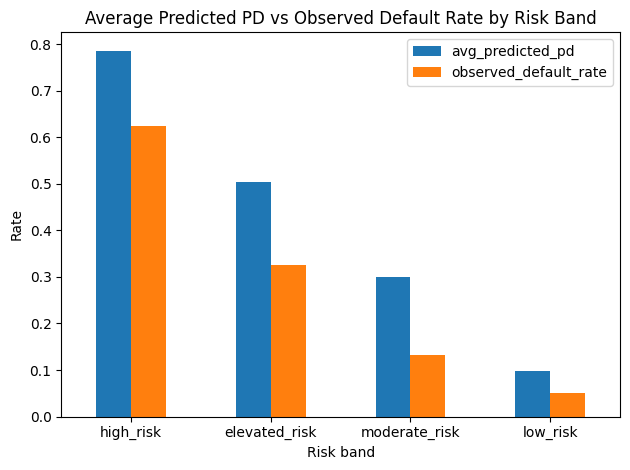

In [19]:

fig, ax = plt.subplots()

calibration_by_band[["avg_predicted_pd", "observed_default_rate"]].plot(kind="bar", ax=ax)

ax.set_title("Average Predicted PD vs Observed Default Rate by Risk Band")
ax.set_xlabel("Risk band")
ax.set_ylabel("Rate")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "07_pd_vs_observed_default_by_band.png", dpi=150)
plt.show();



## Portfolio monitoring flags

The following rules create simple monitoring flags. They are not credit policy rules; they are reporting signals for prioritizing analysis.

Examples:

- High predicted PD and high exposure.
- High expected loss contribution.
- Anomalous profile with elevated PD.
- Cluster with high expected loss share.


In [20]:

high_pd_threshold = portfolio_report["predicted_pd"].quantile(0.75)
high_exposure_threshold = portfolio_report["ead_proxy"].quantile(0.75)
high_el_threshold = portfolio_report["expected_loss_proxy"].quantile(0.90)

portfolio_report["flag_high_pd_high_exposure"] = np.where(
    (portfolio_report["predicted_pd"] >= high_pd_threshold)
    & (portfolio_report["ead_proxy"] >= high_exposure_threshold),
    1,
    0,
)

portfolio_report["flag_high_expected_loss"] = np.where(
    portfolio_report["expected_loss_proxy"] >= high_el_threshold,
    1,
    0,
)

portfolio_report["flag_anomalous_elevated_pd"] = np.where(
    (portfolio_report["ensemble_anomaly_flag"] == 1)
    & (portfolio_report["predicted_pd"] >= high_pd_threshold),
    1,
    0,
)

monitoring_flag_summary = pd.DataFrame(
    {
        "flag": [
            "high_pd_high_exposure",
            "high_expected_loss",
            "anomalous_elevated_pd",
        ],
        "borrowers": [
            int(portfolio_report["flag_high_pd_high_exposure"].sum()),
            int(portfolio_report["flag_high_expected_loss"].sum()),
            int(portfolio_report["flag_anomalous_elevated_pd"].sum()),
        ],
        "borrower_share": [
            portfolio_report["flag_high_pd_high_exposure"].mean(),
            portfolio_report["flag_high_expected_loss"].mean(),
            portfolio_report["flag_anomalous_elevated_pd"].mean(),
        ],
        "expected_loss_share": [
            portfolio_report.loc[portfolio_report["flag_high_pd_high_exposure"] == 1, "expected_loss_proxy"].sum()
            / portfolio_report["expected_loss_proxy"].sum(),
            portfolio_report.loc[portfolio_report["flag_high_expected_loss"] == 1, "expected_loss_proxy"].sum()
            / portfolio_report["expected_loss_proxy"].sum(),
            portfolio_report.loc[portfolio_report["flag_anomalous_elevated_pd"] == 1, "expected_loss_proxy"].sum()
            / portfolio_report["expected_loss_proxy"].sum(),
        ],
    }
)

monitoring_flag_summary


,flag,borrowers,borrower_share,expected_loss_share
0,high_pd_high_exposure,102,0.1020,0.4160
1,high_expected_loss,100,0.1000,0.4487
2,anomalous_elevated_pd,28,0.0280,0.1297



## Executive risk narrative

This section generates a concise written summary of the portfolio.

The output can be reused in the README, a markdown report, or a future Streamlit dashboard.


In [21]:

highest_el_cluster = cluster_summary.sort_values("expected_loss_share", ascending=False).index[0]
highest_el_cluster_share = cluster_summary.loc[highest_el_cluster, "expected_loss_share"]

highest_risk_band = risk_band_summary.sort_values("expected_loss_share", ascending=False).index[0]
highest_risk_band_el_share = risk_band_summary.loc[highest_risk_band, "expected_loss_share"]

anomalous_el_share = (
    anomaly_summary.loc["anomalous_profile", "expected_loss_share"]
    if "anomalous_profile" in anomaly_summary.index
    else np.nan
)

top20_el_share = concentration_summary.loc[
    concentration_summary["concentration_view"] == "top_20_borrowers_expected_loss_share",
    "value",
].iloc[0]

executive_narrative = f"""
# Portfolio Risk Report

The analyzed portfolio contains {portfolio_kpis['number_of_borrowers']:,} borrowers and a total exposure proxy of {portfolio_kpis['total_exposure_proxy']:,.2f}.

The average predicted probability of default is {portfolio_kpis['average_predicted_pd']:.2%}, while the observed default rate is {portfolio_kpis['observed_default_rate']:.2%}. Using an assumed LGD of {LGD_ASSUMPTION:.0%}, the portfolio expected loss proxy is {portfolio_kpis['total_expected_loss_proxy']:,.2f}, equivalent to an expected loss rate proxy of {portfolio_kpis['expected_loss_rate_proxy']:.2%}.

The largest expected loss contribution by supervised risk band comes from `{highest_risk_band}`, which represents {highest_risk_band_el_share:.2%} of total expected loss proxy. The largest expected loss contribution by unsupervised segment comes from cluster `{highest_el_cluster}`, which represents {highest_el_cluster_share:.2%} of total expected loss proxy.

Anomalous borrower profiles represent {portfolio_kpis['anomaly_rate']:.2%} of the portfolio and account for {anomalous_el_share:.2%} of expected loss proxy. The top 20 borrowers by expected loss proxy account for {top20_el_share:.2%} of total expected loss proxy.

These results suggest that portfolio risk should be monitored through multiple lenses: predicted PD, exposure concentration, unsupervised risk clusters, and anomaly detection.
"""

print(executive_narrative)



# Portfolio Risk Report

The analyzed portfolio contains 1,000 borrowers and a total exposure proxy of 3,271,258.00.

The average predicted probability of default is 43.19%, while the observed default rate is 30.00%. Using an assumed LGD of 45%, the portfolio expected loss proxy is 732,747.35, equivalent to an expected loss rate proxy of 22.40%.

The largest expected loss contribution by supervised risk band comes from `high_risk`, which represents 64.65% of total expected loss proxy. The largest expected loss contribution by unsupervised segment comes from cluster `1`, which represents 69.36% of total expected loss proxy.

Anomalous borrower profiles represent 5.00% of the portfolio and account for 18.05% of expected loss proxy. The top 20 borrowers by expected loss proxy account for 14.96% of total expected loss proxy.

These results suggest that portfolio risk should be monitored through multiple lenses: predicted PD, exposure concentration, unsupervised risk clusters, and anomaly 


## Save reporting outputs

This section saves the consolidated portfolio report, summary tables, figures, metadata, and a markdown executive report.


In [22]:

portfolio_report.to_csv(DATA_PROCESSED / "credit_risk_portfolio_report.csv", index=True)

portfolio_kpis_df.to_csv(REPORTS_TABLES / "07_portfolio_kpis.csv", index=False)
risk_band_summary.to_csv(REPORTS_TABLES / "07_risk_band_summary.csv", index=True)
cluster_summary.to_csv(REPORTS_TABLES / "07_cluster_portfolio_summary.csv", index=True)
anomaly_summary.to_csv(REPORTS_TABLES / "07_anomaly_portfolio_summary.csv", index=True)
cluster_band_matrix_share.to_csv(REPORTS_TABLES / "07_cluster_risk_band_matrix.csv", index=True)
concentration_summary.to_csv(REPORTS_TABLES / "07_concentration_summary.csv", index=False)
top_borrowers_by_expected_loss[available_review_columns].to_csv(
    REPORTS_TABLES / "07_top_borrowers_by_expected_loss.csv",
    index=True,
)
calibration_by_band.to_csv(REPORTS_TABLES / "07_calibration_by_risk_band.csv", index=True)
monitoring_flag_summary.to_csv(REPORTS_TABLES / "07_monitoring_flag_summary.csv", index=False)

report_md_path = REPORTS_DIR / "credit_risk_portfolio_report.md"

with open(report_md_path, "w", encoding="utf-8") as f:
    f.write(executive_narrative)
    f.write("\n\n## Portfolio KPIs\n\n")
    f.write(portfolio_kpis_df.to_markdown(index=False))
    f.write("\n\n## Risk Band Summary\n\n")
    f.write(risk_band_summary.to_markdown())
    f.write("\n\n## Cluster Summary\n\n")
    f.write(cluster_summary.to_markdown())
    f.write("\n\n## Monitoring Flags\n\n")
    f.write(monitoring_flag_summary.to_markdown(index=False))

reporting_metadata = {
    "report_layer": "portfolio_risk_reporting",
    "n_borrowers": int(portfolio_kpis["number_of_borrowers"]),
    "total_exposure_proxy": float(portfolio_kpis["total_exposure_proxy"]),
    "average_predicted_pd": float(portfolio_kpis["average_predicted_pd"]),
    "observed_default_rate": float(portfolio_kpis["observed_default_rate"]),
    "total_expected_loss_proxy": float(portfolio_kpis["total_expected_loss_proxy"]),
    "expected_loss_rate_proxy": float(portfolio_kpis["expected_loss_rate_proxy"]),
    "lgd_assumption": float(LGD_ASSUMPTION),
    "highest_expected_loss_risk_band": str(highest_risk_band),
    "highest_expected_loss_cluster": str(highest_el_cluster),
    "anomaly_rate": float(portfolio_kpis["anomaly_rate"]),
}

with open(MODELS_DIR / "portfolio_risk_reporting_metadata.json", "w") as f:
    json.dump(reporting_metadata, f, indent=4)

print(f"Saved consolidated portfolio report to: {DATA_PROCESSED / 'credit_risk_portfolio_report.csv'}")
print(f"Saved markdown executive report to: {report_md_path}")
print("Saved portfolio reporting tables, figures, and metadata.")


Saved consolidated portfolio report to: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/data/processed/credit_risk_portfolio_report.csv
Saved markdown executive report to: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/reports/credit_risk_portfolio_report.md
Saved portfolio reporting tables, figures, and metadata.



## Analytical conclusions

This notebook consolidated the Credit Risk Intelligence Lab into a portfolio-level reporting layer.

The project now has a structured way to move from individual borrower predictions to portfolio risk management. The report combines supervised PD estimates, unsupervised risk clusters, anomaly flags, exposure proxies, expected loss proxies, concentration views, and monitoring flags.

Key outputs:

- Consolidated portfolio risk table.
- Portfolio-level key risk indicators.
- Risk band summary.
- Cluster-level portfolio summary.
- Anomaly portfolio summary.
- Cluster × risk band expected loss matrix.
- Exposure and expected loss concentration views.
- Calibration-style comparison of predicted PD and observed default rate.
- Monitoring flags for high-risk review.
- Markdown executive portfolio risk report.

The next notebook should focus on scenario analysis and stress testing:

```text
notebooks/08_stress_testing.ipynb
```

That stage should apply shocks to PD, LGD, exposure, and high-risk segments in order to evaluate portfolio sensitivity under adverse conditions.
